# Support Vector Machine from Scratch — Pure NumPy

Soft-margin linear SVM trained via **subgradient descent** on the primal objective.

**Dataset:** Breast Cancer (binary, 30 features)  
**Model saved to:** `../Models/svm_scratch.npz`

## 1. Load & Prepare Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

data        = load_breast_cancer()
X_raw       = data.data
# SVM needs labels in {-1, +1} — NOT {0, 1}
y_raw       = np.where(data.target == 1, 1, -1).astype(np.float64)
class_names = list(data.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# Standardise — SVM is distance-based, scale matters
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0) + 1e-8
X_train_sc = (X_train - X_mean) / X_std
X_test_sc  = (X_test  - X_mean) / X_std

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Label distribution — Train: {np.bincount((y_train==1).astype(int))}")

Train: 455  |  Test: 114
Label distribution — Train: [170 285]


## 2. SVM Theory

A linear SVM finds a hyperplane $\mathbf{w}^T\mathbf{x} + b = 0$ that **maximises the margin**
between the two classes.

**Hard-margin primal** (linearly separable):
$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad\text{s.t.}\quad y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1$$

**Soft-margin primal** (allows misclassifications via slack $\xi_i \geq 0$):
$$\min_{\mathbf{w}, b} \underbrace{\frac{1}{2}\|\mathbf{w}\|^2}_{\text{regularisation}} + C\underbrace{\sum_i \max(0,\, 1 - y_i(\mathbf{w}^T\mathbf{x}_i + b))}_{\text{total hinge loss}}$$

- $C$ large → small margin, fewer misclassifications (low bias, high variance)
- $C$ small → large margin, more misclassifications (high bias, low variance)

**Support vectors** are the training points that lie on or inside the margin:
$y_i(\mathbf{w}^T\mathbf{x}_i + b) \leq 1$. Only these points influence $\mathbf{w}$.

**Subgradient for the hinge term:**
$$\frac{\partial}{\partial\mathbf{w}}\max(0, 1-y_i f_i) =
\begin{cases} 0 & \text{if } y_i f_i \geq 1 \quad\text{(correct, outside margin)} \\
-y_i\mathbf{x}_i & \text{if } y_i f_i < 1 \quad\text{(inside margin or wrong side)}
\end{cases}$$

## 3. Hinge Loss & Subgradient

In [2]:
def hinge_loss(X, y, w, b, C):
    """
    Soft-margin SVM primal objective:
    L = (1/2)||w||² + C * sum(max(0, 1 - y*(w·x + b)))
    """
    margins = y * (X @ w + b)                  # (n,)  functional margin
    hinge   = np.maximum(0.0, 1.0 - margins)   # (n,)  per-sample hinge
    return 0.5 * np.dot(w, w) + C * hinge.sum()


def subgradient(X, y, w, b, C):
    """
    Subgradient of the primal objective w.r.t. w and b.
    Points inside the margin (y*f < 1) contribute -y*x to dw.
    """
    margins    = y * (X @ w + b)               # (n,)
    mask       = margins < 1.0                  # bool (n,)  — hinge active

    # dL/dw = w - C * sum_{i: y_i f_i < 1} y_i * x_i
    dw = w - C * (y[mask, np.newaxis] * X[mask]).sum(axis=0)
    db = -C * y[mask].sum()
    return dw, db

## 4. Training Loop (Subgradient Descent)

In [3]:
def train_svm(X, y, C=1.0, lr=1e-3, epochs=1000, lr_decay=True):
    """
    Linear SVM via full-batch subgradient descent.

    lr_decay: use diminishing step size η_t = lr / sqrt(t)
              — guarantees convergence for non-smooth objectives.
    """
    n, p   = X.shape
    w      = np.zeros(p)
    b      = 0.0
    losses = []

    for t in range(1, epochs + 1):
        step = lr / np.sqrt(t) if lr_decay else lr
        dw, db = subgradient(X, y, w, b, C)
        w -= step * dw
        b -= step * db
        losses.append(hinge_loss(X, y, w, b, C))

        if t % 200 == 0 or t == 1:
            pred = np.sign(X @ w + b)
            acc  = np.mean(pred == y)
            print(f"Epoch {t:>5} | Loss: {losses[-1]:.4f} | Train Acc: {acc:.4f}")

    return w, b, losses


C  = 1.0
w, b, losses = train_svm(X_train_sc, y_train, C=C, lr=0.01, epochs=1000)

Epoch     1 | Loss: 461.3165 | Train Acc: 0.9385
Epoch   200 | Loss: 77.4404 | Train Acc: 0.9868
Epoch   400 | Loss: 57.6285 | Train Acc: 0.9890
Epoch   600 | Loss: 47.0382 | Train Acc: 0.9890
Epoch   800 | Loss: 40.1965 | Train Acc: 0.9890
Epoch  1000 | Loss: 35.6933 | Train Acc: 0.9890


## 5. Loss Curve

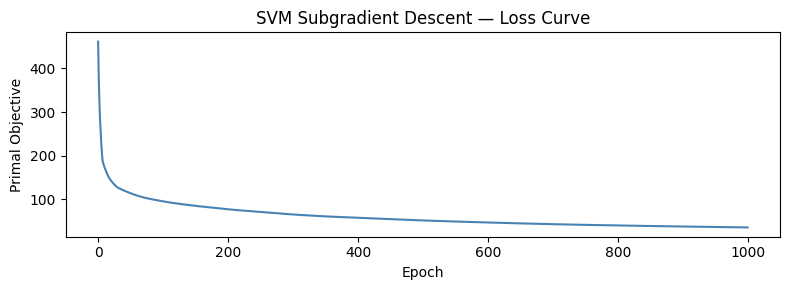

In [4]:
plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Primal Objective')
plt.title('SVM Subgradient Descent — Loss Curve')
plt.tight_layout(); plt.show()

## 6. Evaluate

In [5]:
def predict(X, w, b):
    return np.sign(X @ w + b)   # +1 or -1

y_pred_train = predict(X_train_sc, w, b)
y_pred_test  = predict(X_test_sc,  w, b)

# Convert {-1,+1} back to {0,1} for sklearn metrics
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test,  y_pred_test):.4f}")
print()
labels_01 = np.where(y_test == 1, 1, 0)
preds_01  = np.where(y_pred_test == 1, 1, 0)
print(classification_report(labels_01, preds_01, target_names=class_names))

Train Accuracy: 0.9890
Test  Accuracy: 0.9561

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## 7. Confusion Matrix

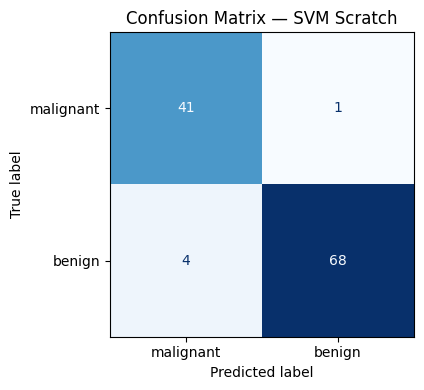

In [6]:
cm   = confusion_matrix(labels_01, preds_01)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — SVM Scratch')
plt.tight_layout(); plt.show()

## 8. Support Vectors

Support vectors are the training points with $y_i(\mathbf{w}^T\mathbf{x}_i + b) \leq 1$.
They are the only points that contribute to the gradient — the rest of the data is irrelevant
once training is done.

In [7]:
margins    = y_train * (X_train_sc @ w + b)
sv_mask    = margins <= 1.0 + 1e-4          # on or inside the margin
n_sv       = sv_mask.sum()
sv_margins = margins[sv_mask]

print(f"Support vectors: {n_sv} / {len(X_train)} ({100*n_sv/len(X_train):.1f}%)")
print(f"Margin (geometric): {2 / np.linalg.norm(w):.4f}")
print(f"Min functional margin of SVs: {sv_margins.min():.4f}")

Support vectors: 12 / 455 (2.6%)
Margin (geometric): 0.3690
Min functional margin of SVs: -8.8066


## 9. Decision Boundary (PCA 2D Projection)

Project data to 2D using PCA for visualisation. The hyperplane is a line in this space.

Epoch     1 | Loss: 530.6542 | Train Acc: 0.9363
Epoch   200 | Loss: 123.0707 | Train Acc: 0.9626
Epoch   400 | Loss: 96.0231 | Train Acc: 0.9626
Epoch   600 | Loss: 80.3212 | Train Acc: 0.9626
Epoch   800 | Loss: 71.0271 | Train Acc: 0.9582
Epoch  1000 | Loss: 65.4915 | Train Acc: 0.9604
Epoch  1200 | Loss: 61.8888 | Train Acc: 0.9604
Epoch  1400 | Loss: 60.3403 | Train Acc: 0.9626
Epoch  1600 | Loss: 59.5740 | Train Acc: 0.9626
Epoch  1800 | Loss: 59.0144 | Train Acc: 0.9626
Epoch  2000 | Loss: 58.7178 | Train Acc: 0.9604


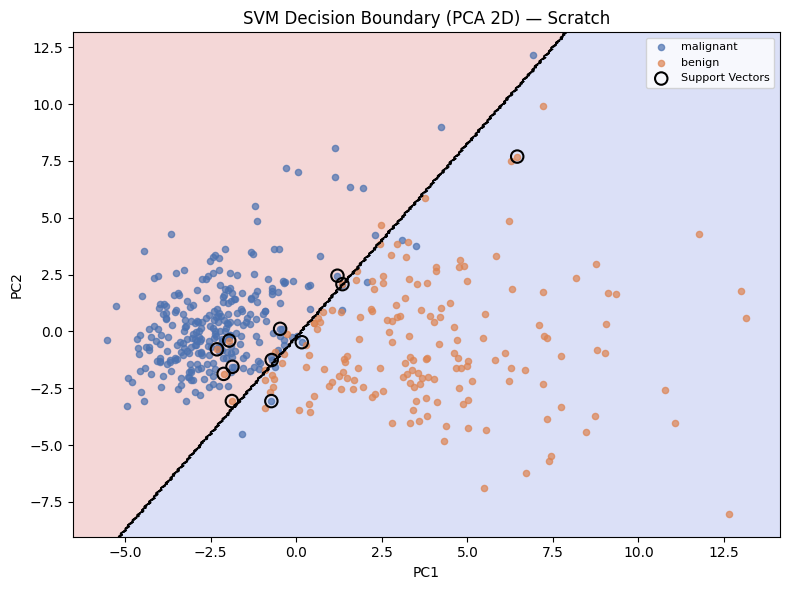

In [8]:
from sklearn.decomposition import PCA

pca   = PCA(n_components=2).fit(X_train_sc)
X2_tr = pca.transform(X_train_sc)
X2_te = pca.transform(X_test_sc)

# Train a 2D SVM for visualisation
w2, b2, _ = train_svm(X2_tr, y_train, C=C, lr=0.01, epochs=2000)

x_min, x_max = X2_tr[:, 0].min()-1, X2_tr[:, 0].max()+1
y_min, y_max = X2_tr[:, 1].min()-1, X2_tr[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = np.sign(np.c_[xx.ravel(), yy.ravel()] @ w2 + b2).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
ax.contour(xx, yy, Z, colors='k', linewidths=0.8)

colors = {1: '#4C72B0', -1: '#DD8452'}
for label, name in zip([1, -1], class_names):
    mask = y_train == label
    ax.scatter(X2_tr[mask, 0], X2_tr[mask, 1],
               c=colors[label], label=name, s=20, alpha=0.7)

# Highlight support vectors
sv_2d = X2_tr[sv_mask]
ax.scatter(sv_2d[:, 0], sv_2d[:, 1], s=80, facecolors='none',
           edgecolors='black', linewidths=1.5, label='Support Vectors')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('SVM Decision Boundary (PCA 2D) — Scratch')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10. C Hyperparameter Sweep

Epoch     1 | Loss: 0.4381 | Train Acc: 0.9385
Epoch   200 | Loss: 0.2034 | Train Acc: 0.9407
Epoch   400 | Loss: 0.1873 | Train Acc: 0.9429
Epoch   600 | Loss: 0.1811 | Train Acc: 0.9429
Epoch   800 | Loss: 0.1781 | Train Acc: 0.9451
Epoch  1000 | Loss: 0.1762 | Train Acc: 0.9473
Epoch     1 | Loss: 2.9038 | Train Acc: 0.9385
Epoch   200 | Loss: 0.7720 | Train Acc: 0.9758
Epoch   400 | Loss: 0.7469 | Train Acc: 0.9780
Epoch   600 | Loss: 0.7363 | Train Acc: 0.9802
Epoch   800 | Loss: 0.7314 | Train Acc: 0.9802
Epoch  1000 | Loss: 0.7280 | Train Acc: 0.9802
Epoch     1 | Loss: 8.3689 | Train Acc: 0.9385
Epoch   200 | Loss: 3.5925 | Train Acc: 0.9846
Epoch   400 | Loss: 3.5264 | Train Acc: 0.9868
Epoch   600 | Loss: 3.4892 | Train Acc: 0.9868
Epoch   800 | Loss: 3.4663 | Train Acc: 0.9868
Epoch  1000 | Loss: 3.4547 | Train Acc: 0.9868
Epoch     1 | Loss: 461.3165 | Train Acc: 0.9385
Epoch   200 | Loss: 77.4404 | Train Acc: 0.9868
Epoch   400 | Loss: 57.6285 | Train Acc: 0.9890
Epoch   6

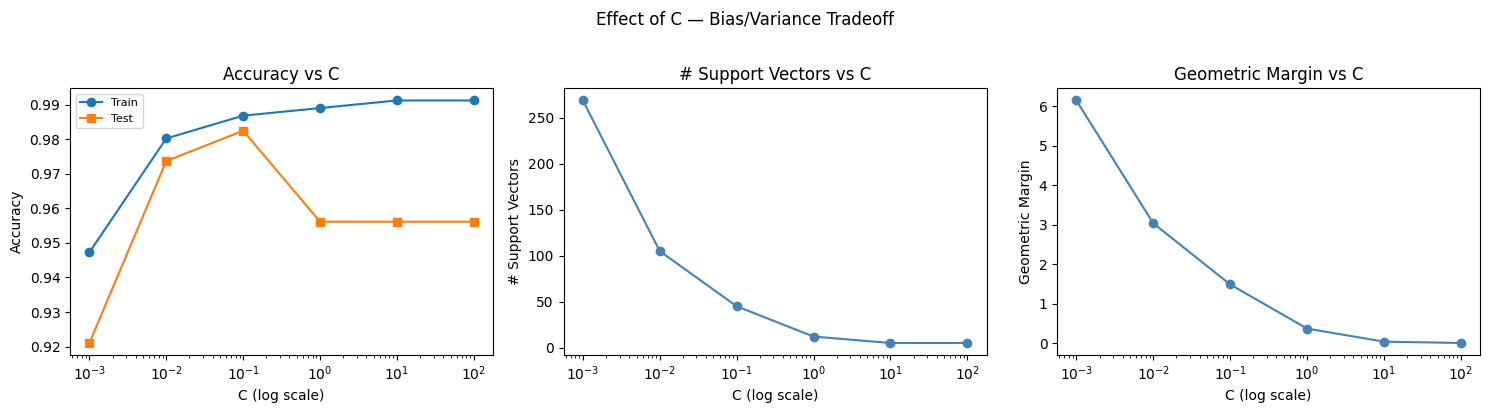

In [9]:
C_values   = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
tr_accs, te_accs, n_svs, margins_list = [], [], [], []

for c in C_values:
    wc, bc, _ = train_svm(X_train_sc, y_train, C=c, lr=0.01, epochs=1000)
    tr_accs.append(accuracy_score(y_train, predict(X_train_sc, wc, bc)))
    te_accs.append(accuracy_score(y_test,  predict(X_test_sc,  wc, bc)))
    n_svs.append((y_train * (X_train_sc @ wc + bc) <= 1.0 + 1e-4).sum())
    margins_list.append(2 / np.linalg.norm(wc))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, title in zip(axes,
    [list(zip(tr_accs, te_accs)), n_svs, margins_list],
    ['Accuracy', '# Support Vectors', 'Geometric Margin']):

    if title == 'Accuracy':
        tr, te = zip(*vals)
        ax.semilogx(C_values, tr, marker='o', label='Train')
        ax.semilogx(C_values, te, marker='s', label='Test')
        ax.legend(fontsize=8)
    else:
        ax.semilogx(C_values, vals, marker='o', color='steelblue')
    ax.set_xlabel('C (log scale)'); ax.set_ylabel(title)
    ax.set_title(f'{title} vs C')

plt.suptitle('Effect of C — Bias/Variance Tradeoff', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## 11. Save Model to `../Models/`

In [10]:
os.makedirs('../Models', exist_ok=True)

np.savez_compressed('../Models/svm_scratch.npz',
    w=w, b=np.array(b), C=np.array(C),
    x_mean=X_mean, x_std=X_std
)
print(f"Saved → ../Models/svm_scratch.npz  "
      f"({os.path.getsize('../Models/svm_scratch.npz')/1024:.1f} KB)")

Saved → ../Models/svm_scratch.npz  (1.6 KB)
